In [2]:
import matplotlib.pyplot as plt
import numpy as np

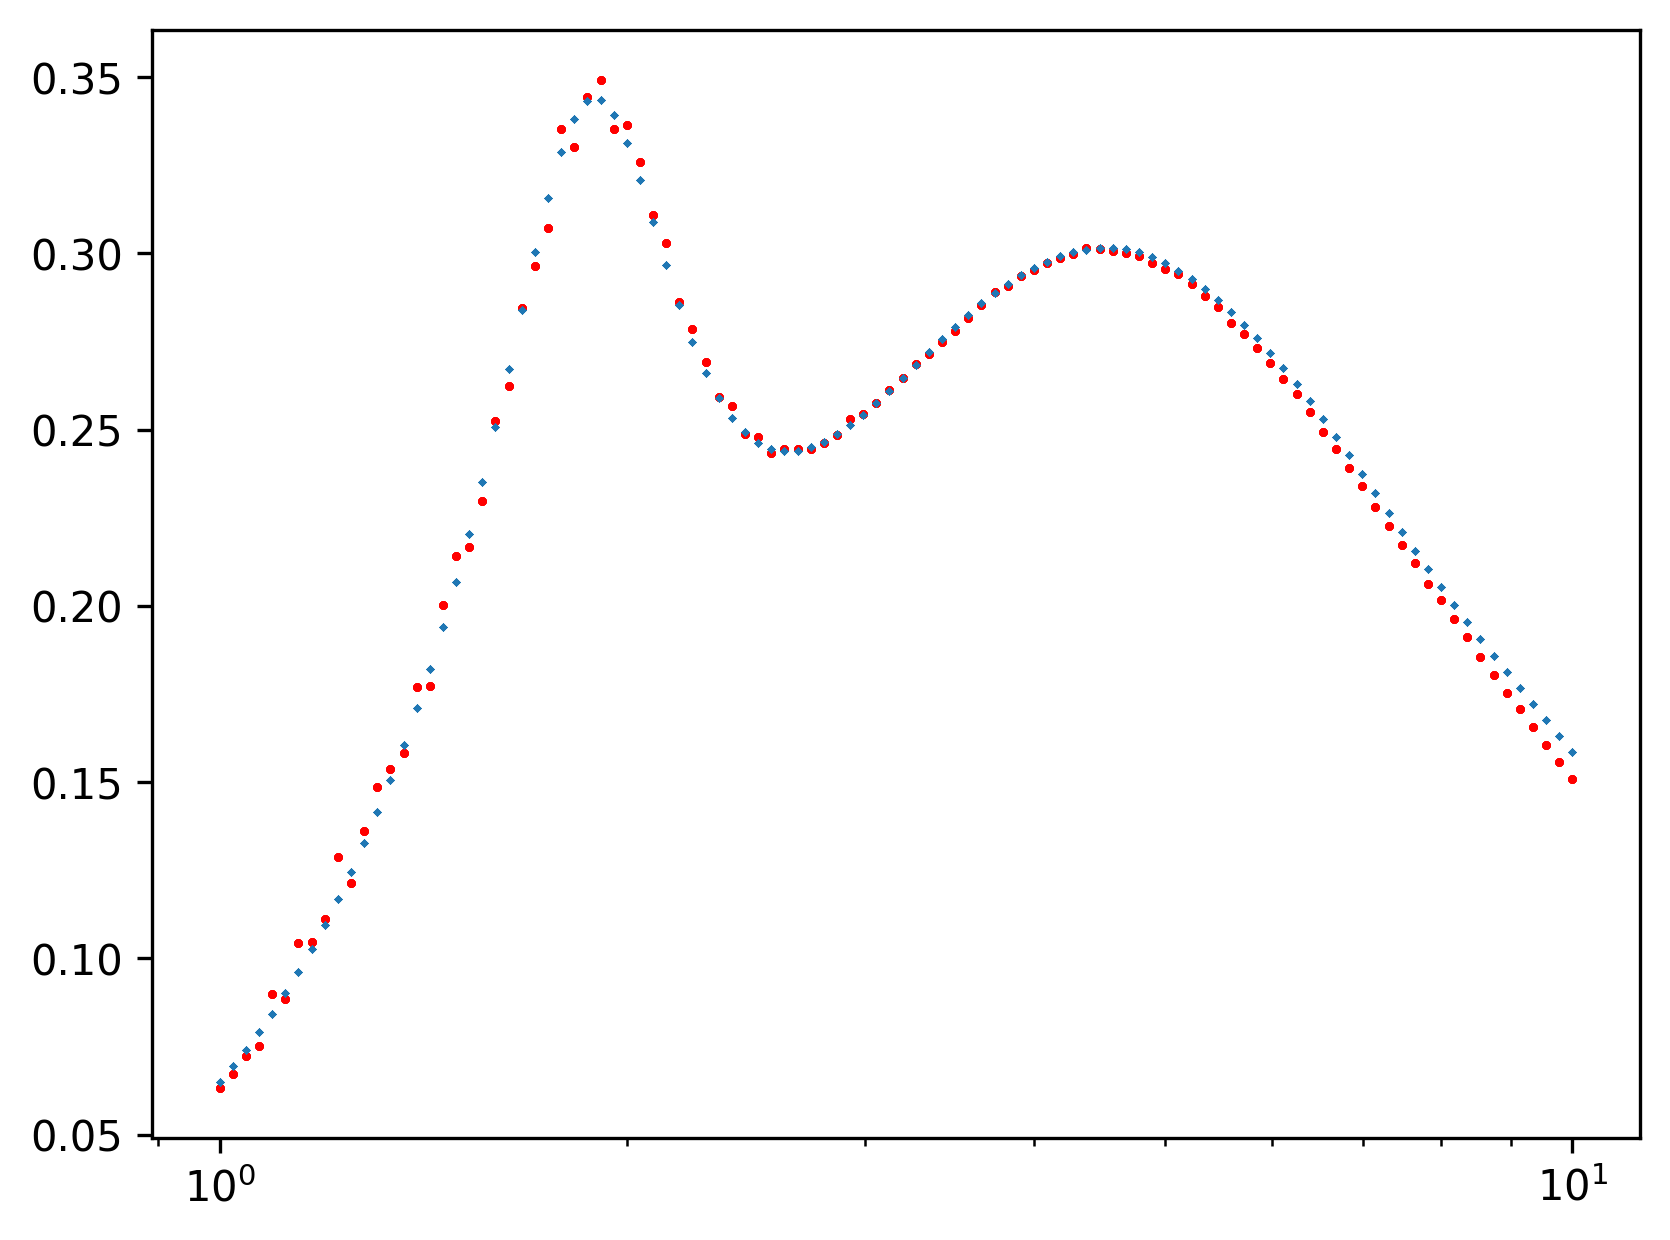

In [8]:
plt.figure(dpi=300)
plt.xscale("log")
# a = np.loadtxt(f"apamea_N320.out")
# plt.scatter(a[:, 0], a[:, 1], s=1, c="red")
# a = np.loadtxt("apamea_N320_thermo.csv", delimiter=",", skiprows=1)
# plt.scatter(a[:, 0], a[:, 3] / 320, s=1, marker="x")
N=320

for i in range(10):
    a = np.loadtxt(f"apamea_N{N}.out")
    plt.scatter(a[:, 0], a[:, 1], s=1, c="red")
i=7
a = np.loadtxt(f"apamea_N{N}_thermo.csv", delimiter=",", skiprows=1)
plt.scatter(a[:, 0], a[:, 3] / N, s=1, marker="x")
# plt.ylim(0, 1)

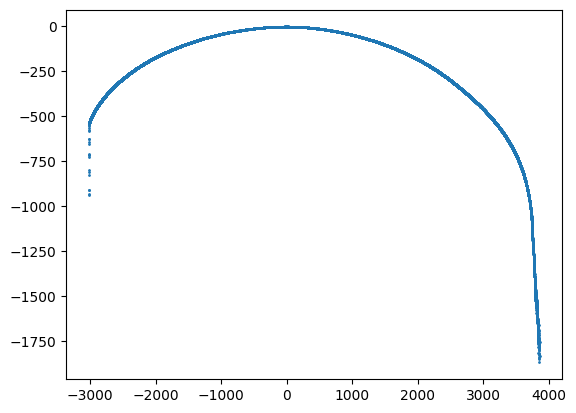

In [4]:
b = np.loadtxt(f"apamea_N720_{i}_dos.csv", delimiter=",", skiprows=1)
# plt.yscale("log")
# plt.scatter(b[:, 1], np.exp(b[:, 2]), s=1)
plt.scatter(b[:, 1], b[:, 2], s=1)


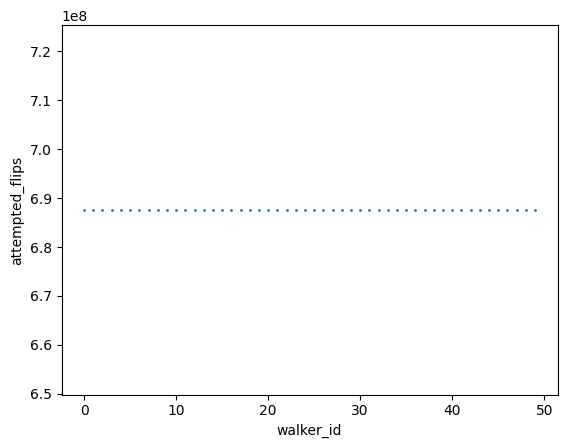

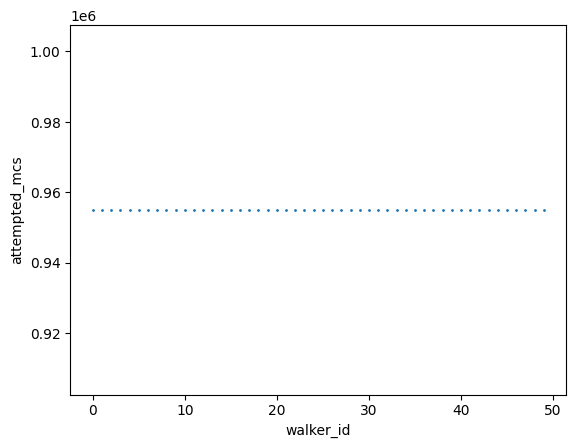

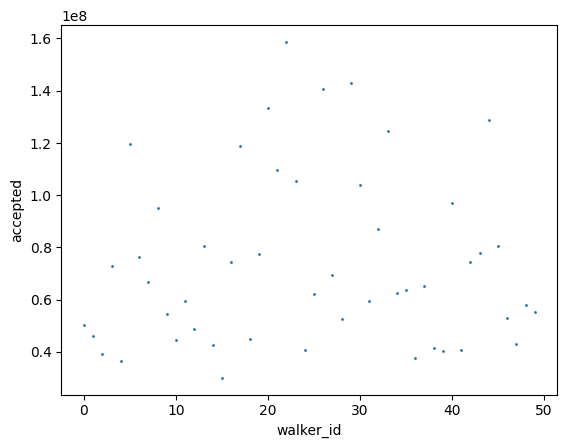

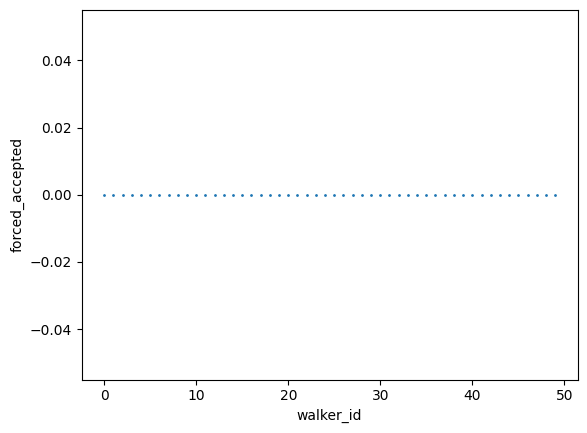

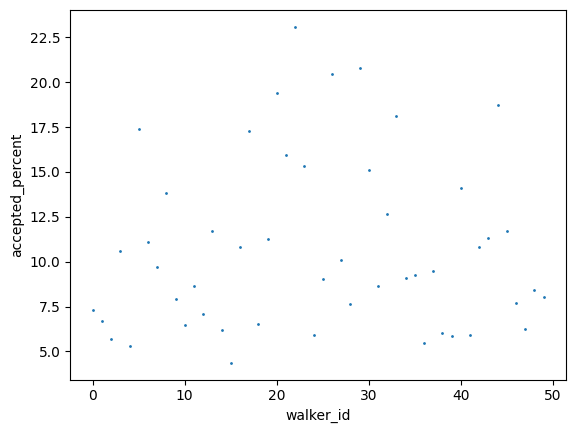

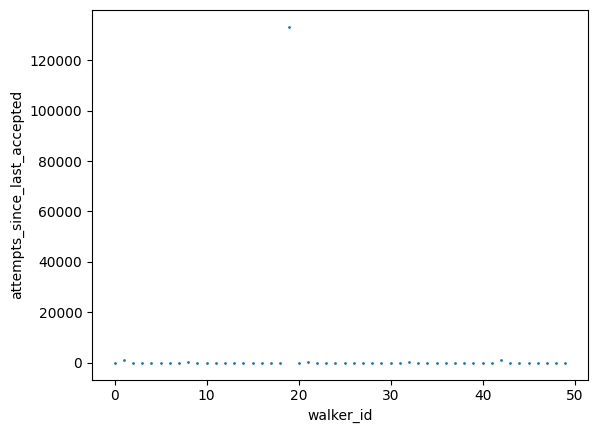

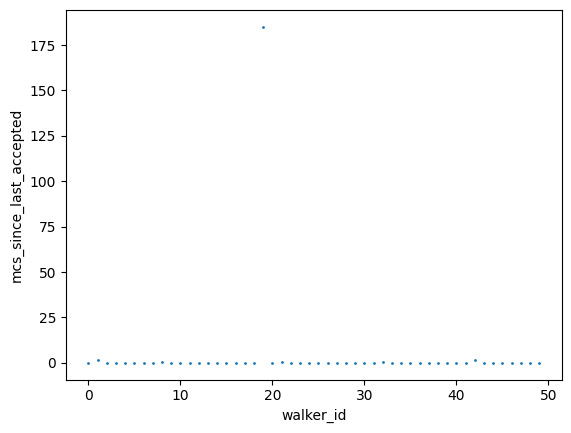

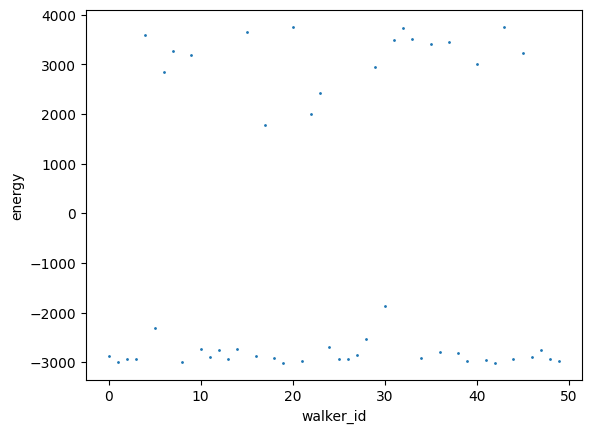

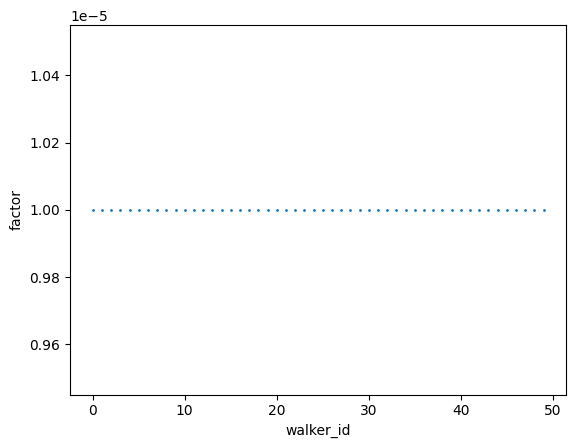

In [5]:
b = np.loadtxt("apamea_N720_workers_stat.csv", delimiter=",", skiprows=1)
title = open("apamea_N720_workers_stat.csv").readline().strip().split(",")
for i in range(3, 12):
    plt.scatter(b[:, 2], b[:, i], s=1)
    plt.xlabel(title[2])
    plt.ylabel(title[i])
    # plt.yscale("log")
    plt.show()


Text(0, 0.5, 'logg')

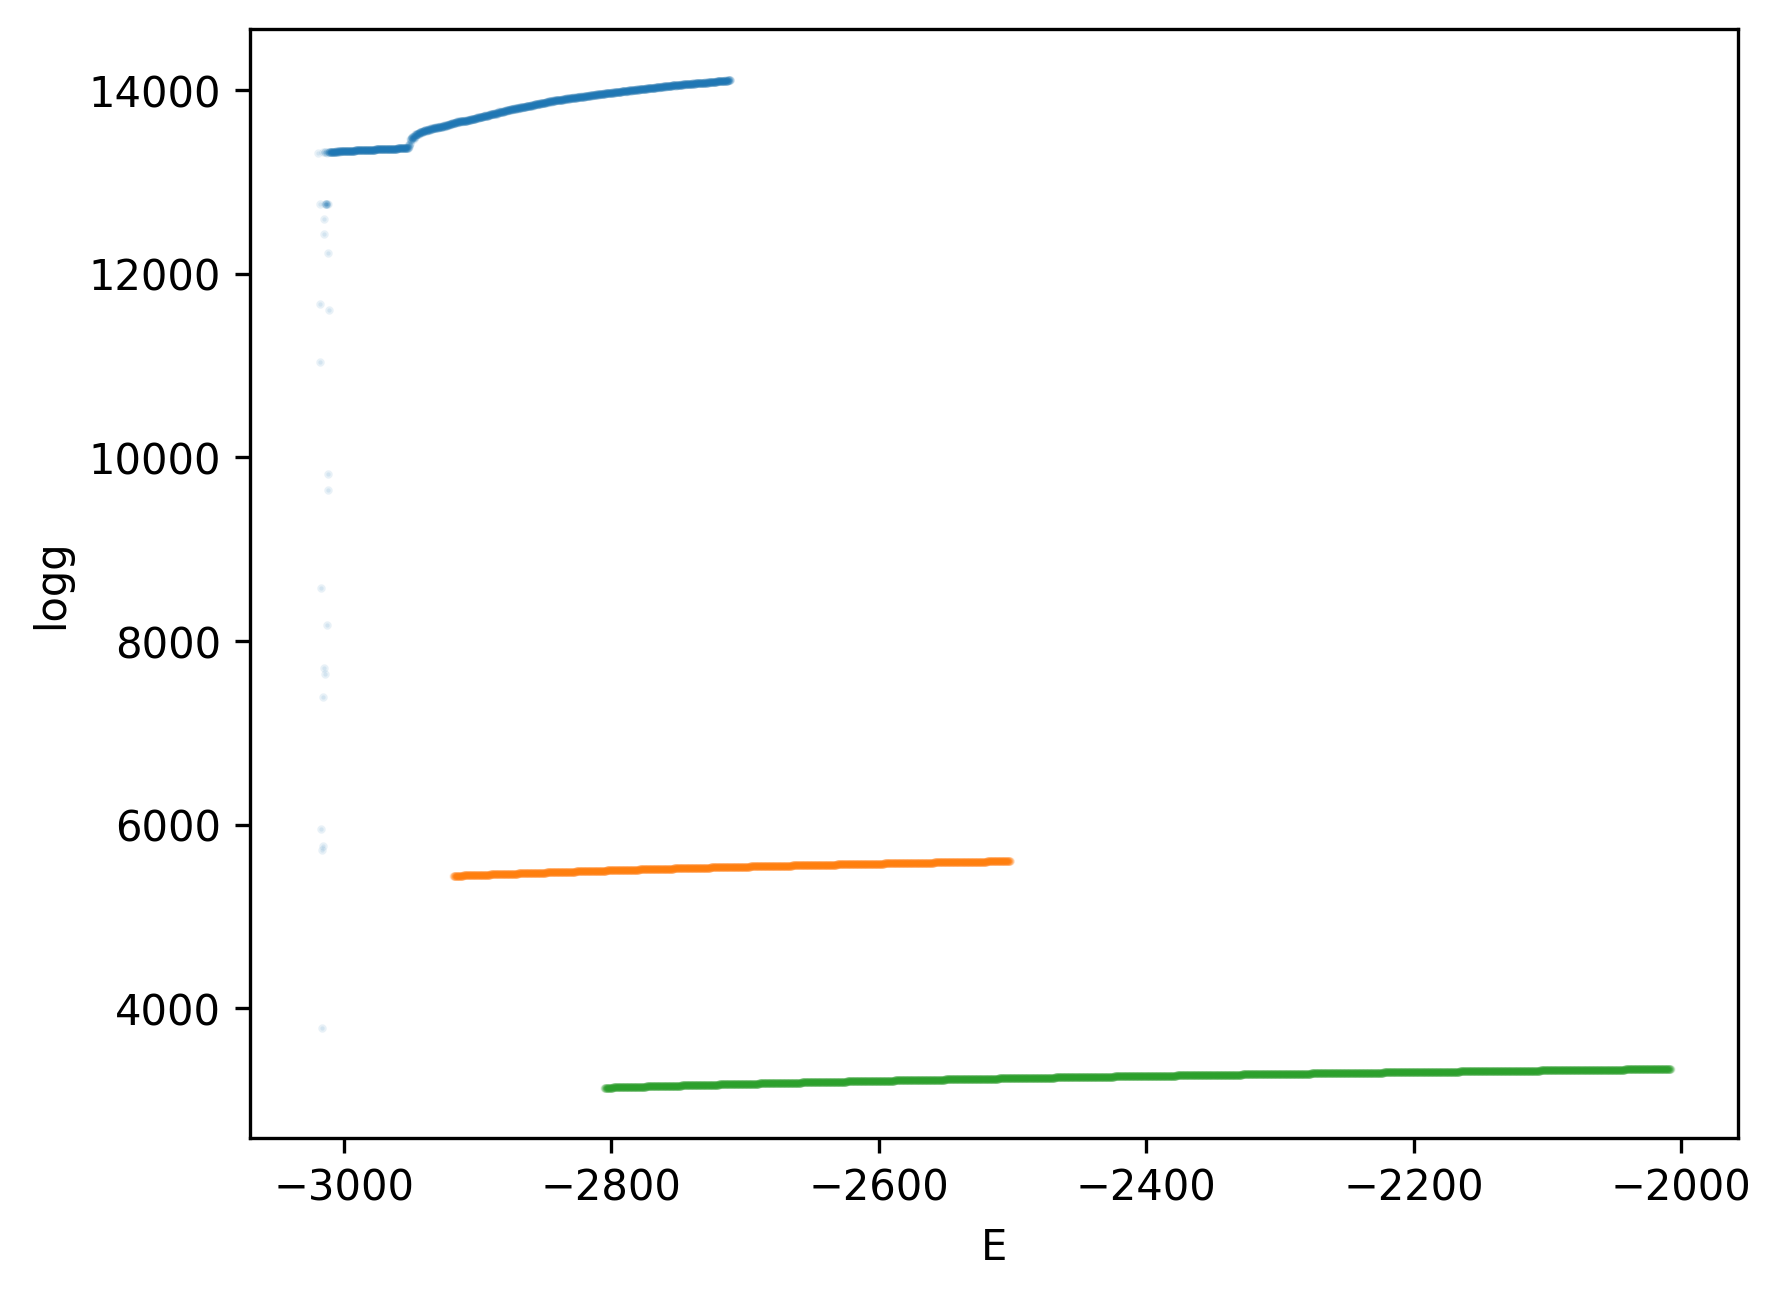

In [6]:
plt.figure(dpi=300)
for i in range(3):
    a = np.loadtxt(f"apamea_N720_window_{i}.csv", delimiter=",", skiprows=1)
    plt.scatter(a[:, 2], a[:, 3], s=1, alpha=0.1)
plt.xlabel("E")
plt.ylabel("logg")
#     plt.axvline(a[0, 2] + (a[-1, 2] - a[0, 2]) * 0.1)
#     plt.axvline(a[-1, 2] - (a[-1, 2] - a[0, 2]) * 0.1)
# (a[-1, 2] - a[0, 2])* 0.1

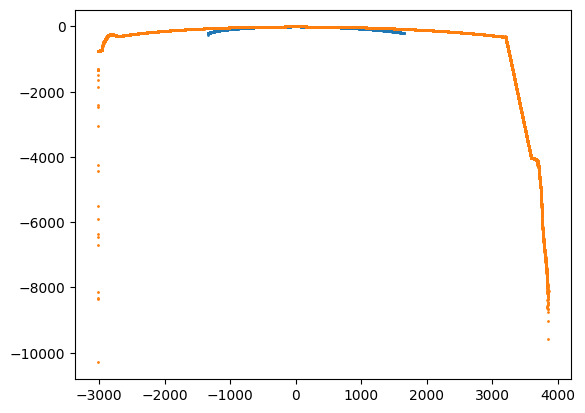

In [7]:
a = np.loadtxt(f"apamea_N320_dos.csv", delimiter=",", skiprows=1)
plt.scatter(a[:, 1], a[:, 2], s=1)

a = np.loadtxt(f"apamea_N720_dos.csv", delimiter=",", skiprows=1)
plt.scatter(a[:, 1], a[:, 2], s=1)

In [8]:
plt.scatter(a[a[:, 8]==1][:, 3], a[a[:, 8]==1][:, 2], s=1, c="red", label="dos2d")

IndexError: index 8 is out of bounds for axis 1 with size 8

In [ ]:
for i in range(3):
    print(f'sbatch -p common -N 1 -o "apamea_N720_{i}.log" --exclusive -J "wl" start.sh --config apamea/apamea_N720.ini --progress 600 --output apamea_N720_{i}')

sbatch -p common -N 1 -o "apamea_N720_0.log" --exclusive -J "wl" start.sh --config apamea/apamea_N720.ini --progress 600 --output apamea_N720_0
sbatch -p common -N 1 -o "apamea_N720_1.log" --exclusive -J "wl" start.sh --config apamea/apamea_N720.ini --progress 600 --output apamea_N720_1
sbatch -p common -N 1 -o "apamea_N720_2.log" --exclusive -J "wl" start.sh --config apamea/apamea_N720.ini --progress 600 --output apamea_N720_2


In [ ]:
for i in range(3):
    print(f'sbatch -p common -n 10 -o "apamea_N720_{i}.log" --exclusive -J "rewl" start_mpi.sh --config apamea/apamea_N720.ini --progress 600 --output apamea_N720_{i}')

sbatch -p common -n 10 -o "apamea_N720_0.log" --exclusive -J "rewl" start_mpi.sh --config apamea/apamea_N720.ini --progress 600 --output apamea_N720_0
sbatch -p common -n 10 -o "apamea_N720_1.log" --exclusive -J "rewl" start_mpi.sh --config apamea/apamea_N720.ini --progress 600 --output apamea_N720_1
sbatch -p common -n 10 -o "apamea_N720_2.log" --exclusive -J "rewl" start_mpi.sh --config apamea/apamea_N720.ini --progress 600 --output apamea_N720_2


In [ ]:
# Варианты: 
# 1 окно 50 потоков 
# 10 окон в 5 потоков
# 20 окон в 1 поток

In [ ]:
commands = ['sbatch -p common -o "apamea_N720_{0}.log" --exclusive -J "wl" start.sh --config apamea/apamea_N720.ini --progress 600 --output apamea_N720_{0} --windows 1 --walkers 50 --final-factor 1e-5',
 'sbatch -p common -n 10 -o "apamea_N720_{0}.log" --exclusive -J "rewl10" start_mpi.sh --config apamea/apamea_N720.ini --progress 600 --output apamea_N720_{0} --windows 10 --walkers 5 --final-factor 1e-5',
 'sbatch -p common -n 20 -o "apamea_N720_{0}.log" --exclusive -J "rewl20" start_mpi.sh --config apamea/apamea_N720.ini --progress 600 --output apamea_N720_{0} --windows 20 --walkers 1 --final-factor 1e-5',
 'sbatch -p common -o "apamea_N720_{0}.log" --exclusive -J "wl" start.sh --config apamea/apamea_N720.ini --progress 600 --output apamea_N720_{0} --windows 1 --walkers 50 --final-factor 1e-4',
 'sbatch -p common -n 10 -o "apamea_N720_{0}.log" --exclusive -J "rewl10" start_mpi.sh --config apamea/apamea_N720.ini --progress 600 --output apamea_N720_{0} --windows 10 --walkers 5 --final-factor 1e-4',
 'sbatch -p common -n 20 -o "apamea_N720_{0}.log" --exclusive -J "rewl20" start_mpi.sh --config apamea/apamea_N720.ini --progress 600 --output apamea_N720_{0} --windows 20 --walkers 1 --final-factor 1e-4',
 'sbatch -p common -n 30 -o "apamea_N720_{0}.log" --exclusive -J "rewl30" start_mpi.sh --config apamea/apamea_N720.ini --progress 600 --output apamea_N720_{0} --windows 30 --walkers 1 --final-factor 1e-5',
 'sbatch -p common -o "apamea_N720_{0}.log" --exclusive -J "wl" start.sh --config apamea/apamea_N720.ini --progress 600 --output apamea_N720_{0} --windows 1 --walkers 50 --final-factor 1e-6']

for i in range(len(commands)):
    print(commands[i].format(i))


sbatch -p common -o "apamea_N720_0.log" --exclusive -J "wl" start.sh --config apamea/apamea_N720.ini --progress 600 --output apamea_N720_0 --windows 1 --walkers 50 --final-factor 1e-5
sbatch -p common -n 10 -o "apamea_N720_1.log" --exclusive -J "rewl10" start_mpi.sh --config apamea/apamea_N720.ini --progress 600 --output apamea_N720_1 --windows 10 --walkers 5 --final-factor 1e-5
sbatch -p common -n 20 -o "apamea_N720_2.log" --exclusive -J "rewl20" start_mpi.sh --config apamea/apamea_N720.ini --progress 600 --output apamea_N720_2 --windows 20 --walkers 1 --final-factor 1e-5
sbatch -p common -o "apamea_N720_3.log" --exclusive -J "wl" start.sh --config apamea/apamea_N720.ini --progress 600 --output apamea_N720_3 --windows 1 --walkers 50 --final-factor 1e-4
sbatch -p common -n 10 -o "apamea_N720_4.log" --exclusive -J "rewl10" start_mpi.sh --config apamea/apamea_N720.ini --progress 600 --output apamea_N720_4 --windows 10 --walkers 5 --final-factor 1e-4
sbatch -p common -n 20 -o "apamea_N720

Text(0.5, 1.0, 'accepted_percent')

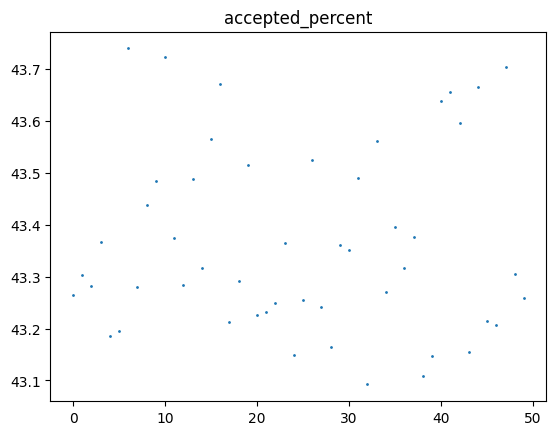

In [27]:
a = np.loadtxt(f"apamea_N320_workers_stat.csv", delimiter=",", skiprows=1)
t = "mpi_rank,window,walker_id,attempted_flips,attempted_mcs,accepted,forced_accepted,accepted_percent,attempts_since_last_accepted,mcs_since_last_accepted,energy,factor,active_bins,min_h,mean_h,min_over_mean,round_trips".split(",")
i=7
plt.scatter(a[:, 2], a[:, i], s=1)
plt.title(t[i])